In [1]:
!pip install pandas
import pandas as pd

# Wczytujemy dane
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Pokazujemy początek tabeli
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# 1. Naprawa TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Usuwamy wiersze, które po powyższej operacji stały się puste
df.dropna(inplace=True)

# 3. Usuwamy ID klienta
df.drop('customerID', axis=1, inplace=True)

# 4. Sprawdzenie
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

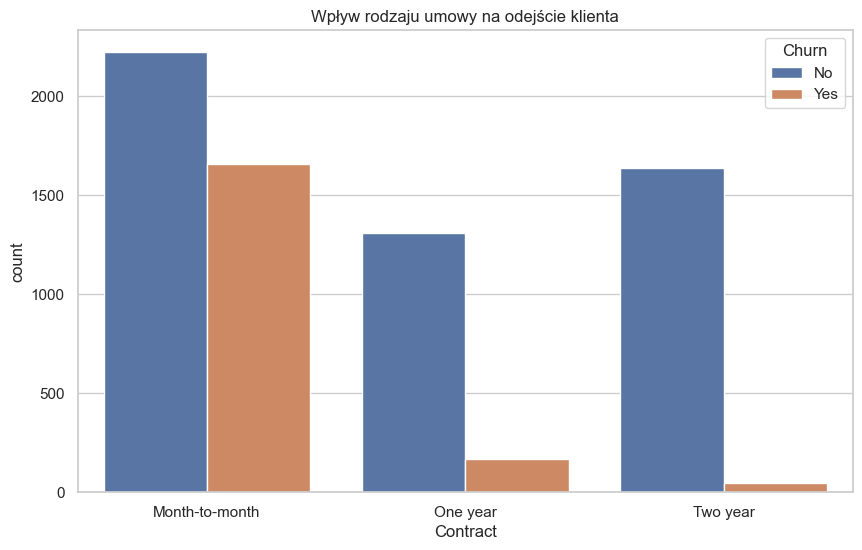

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ustawienie stylu wykresów
sns.set(style="whitegrid")

# Wykres: Czy typ umowy (Contract) ma wpływ na Churn (odejście)?
plt.figure(figsize=(10, 6))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Wpływ rodzaju umowy na odejście klienta')
plt.show()

In [1]:
# Zamiana wszystkich kolumn tekstowych na liczbowe (0 i 1)
# Używam funkcji get_dummies - dla całego arkusza
df_final = pd.get_dummies(df, drop_first=True)

# Sprawdzenie danych
df_final.head()

NameError: name 'pd' is not defined

In [2]:
import pandas as pd 

# Zamiana kolumn tekstowych na liczbowe
df_final = pd.get_dummies(df, drop_first=True)

# Sprawdzenie danych
df_final.head()

NameError: name 'df' is not defined

In [3]:
import pandas as pd

# Wczytuje dane jeszcze raz, żeby Python na pewno je pamiętał
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Czyszczę TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

# Zamiana kolumn tekstowych na liczbowe
df_final = pd.get_dummies(df, drop_first=True)

# Sprawdzenie
df_final.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Rozdzielenie danych na X (cechy) i y (wynik: Churn_Yes)
X = df_final.drop('Churn_Yes', axis=1)
y = df_final['Churn_Yes']

# 2. Dzielenie danych na treningowe (80%) i testowe (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Stworzenie modelu i trening
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Sprawdzenie na danych, nowe dane testowe
predykcje = model.predict(X_test)

# 5. Wyświetlenie raportu skuteczności
print("Raport klasyfikacji:")
print(classification_report(y_test, predykcje))

Raport klasyfikacji:
              precision    recall  f1-score   support

       False       0.83      0.90      0.86      1033
        True       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



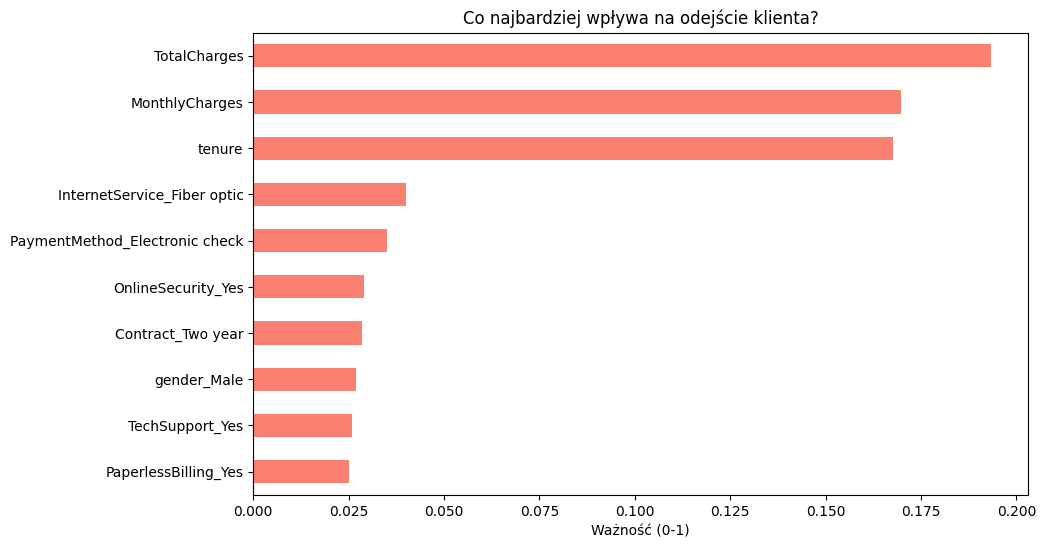

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Pobranie cech
importances = pd.Series(model.feature_importances_, index=X.columns)

# Wykres 10 najważniejszych cech
plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='salmon')
plt.title('Co najbardziej wpływa na odejście klienta?')
plt.xlabel('Ważność (0-1)')
plt.gca().invert_yaxis()
plt.show()